In [12]:
import torch
import torch.nn as nn
import pandas as pd
from torch.optim import AdamW
from transformers import RobertaModel
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForMaskedLM, pipeline
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA toolkit version:", torch.version.cuda)
print("Device name:", torch.cuda.get_device_name(0))

Torch version: 2.7.1+cu118
CUDA available: True
CUDA toolkit version: 11.8
Device name: NVIDIA GeForce RTX 3050 Laptop GPU


In [13]:
pipe = pipeline("fill-mask", model="NLPC-UOM/SinBERT-large")
tokenizer = AutoTokenizer.from_pretrained("NLPC-UOM/SinBERT-large")
model = AutoModelForMaskedLM.from_pretrained("NLPC-UOM/SinBERT-large")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

In [15]:
df = pd.read_csv('./processed/processed_dataset.csv')
print(f"Dataset shape: {df.shape}")
print(f"Label distribution:\n{df['label'].value_counts()}")

Dataset shape: (3800, 2)
Label distribution:
label
joy         1050
disgust      720
sadness      679
anger        597
surprise     576
fear         178
Name: count, dtype: int64


In [16]:
class_sample_count

array([ 597,  720,  178, 1050,  679,  576])

## Creating the DataSet Class


the class wich represent the data.the dataloder will use this class to load the data one by one or in batches.it relies on 2 methods.

- `__len__`    - returns the length of the dataset
- `__getitem__` - returns the item at the given index
Also it has the constructor which takes the dataframe, tokenizer and max_length as input parameters.
- `__init__`- constructor to initialize the dataset with a dataframe, tokenizer, and maximum sequence length.
    - `self.text`,`self.label` - store the raw sinhala texts and labels from the dataframe.
    - `self.tokenizer` - stores the tokenizer object.
    - `self.max_length` - stores the maximum length of the input sequence.all the sentences will be padded or truncated to this length.

In [17]:
class SinhalaEmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        # Create label-to-index mapping
        self.label2idx = {label: idx for idx, label in enumerate(sorted(set(labels)))}
        self.labels = [self.label2idx[label] for label in labels]
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

## Dataloader

In [18]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

# Compute class weights from training data only
train_labels_arr = df_train['label'].values
unique_classes = np.unique(train_labels_arr)
class_sample_count = np.array([np.sum(train_labels_arr == t) for t in unique_classes])
weight = 1. / class_sample_count
class_weights = torch.tensor(weight, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
print(f"Class weights (training data only): {dict(zip(unique_classes, weight.round(4)))}")

# Dataset and Dataloader
BATCH_SIZE = 16
train_dataset = SinhalaEmotionDataset(
    texts=df_train['text'].tolist(),
    labels=df_train['label'].tolist(),
    tokenizer=tokenizer
)
test_dataset = SinhalaEmotionDataset(
    texts=df_test['text'].tolist(),
    labels=df_test['label'].tolist(),
    tokenizer=tokenizer
)
train_data_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_data_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print("Data Loaders for training, validation, and testing are ready.")

Class weights (training data only): {'anger': np.float64(0.0021), 'disgust': np.float64(0.0017), 'fear': np.float64(0.007), 'joy': np.float64(0.0012), 'sadness': np.float64(0.0018), 'surprise': np.float64(0.0022)}
Data Loaders for training, validation, and testing are ready.


## Building the Model Architecture


every pytorch model should inherit from `nn.Module` class. The model should have the following methods.
- `__init__` - constructor to initialize the model with a pre-trained BERT model and a CNN layer.
    - `self.bert` - stores the pre-trained BERT model.
    - `self.cnn` - stores the CNN layer.
    - `self.relu` - stores the ReLU activation function.
    - `self.pool` - stores the adaptive max pooling layer.

In [19]:
class SinbertCNN(nn.Module):
    """
    SinbertCNN combines a RoBERTa-based encoder with CNN layers for emotion classification.
    Args:
        num_labels (int): Number of output classes.
        embedding_dim (int): Dimensionality of SinBERT embeddings.
        num_filters (int): Number of filters per CNN layer.
        kernel_sizes (list): List of kernel sizes for CNN layers.
        dropout_rate (float): Dropout rate for regularization.
        pretrained_model_name (str): Name of the pretrained RoBERTa model.
    """
    def __init__(self, num_labels, embedding_dim=768, num_filters=100, kernel_sizes=None, dropout_rate=0.5, pretrained_model_name="NLPC-UOM/SinBERT-large"):
        super(SinbertCNN, self).__init__()

        if kernel_sizes is None:
            kernel_sizes = [3, 4, 5]
        self.sinbert = RobertaModel.from_pretrained(pretrained_model_name)
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embedding_dim,
                      out_channels=num_filters,
                      kernel_size=k)
            for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_labels)

    def forward(self, input_ids, attention_mask):

        outputs = self.sinbert(input_ids=input_ids, attention_mask=attention_mask)
        embeddings = outputs.last_hidden_state
        x = embeddings.permute(0, 2, 1)
        conv_outputs = [torch.relu(conv(x)) for conv in self.convs]
        pooled_outputs = [torch.max(conv_output, dim=2)[0] for conv_output in conv_outputs]
        concatenated_output = torch.cat(pooled_outputs, dim=1)
        dropout_output = self.dropout(concatenated_output)
        logits = self.fc(dropout_output)
        return logits

## Training the Model

In [20]:
import torch

def train_model_with_early_stopping(model, train_loader, val_loader, criterion, optimizer, device, epochs=10, patience=2):
    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item() * input_ids.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).float().sum().item()
            total += labels.size(0)
        epoch_loss = running_loss / total
        epoch_acc = correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        # Validation
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * input_ids.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).float().sum().item()
                val_total += labels.size(0)
        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                model.load_state_dict(best_model_state)
                break

    return train_losses, train_accuracies, val_losses, val_accuracies

In [21]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def evaluate_metrics(model, data_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')
    return acc, precision, recall, f1


#### Hyper parameter Tuning

In [22]:
# Python
from transformers import AutoConfig

config = AutoConfig.from_pretrained("NLPC-UOM/SinBERT-large")
print("Hidden size:", config.hidden_size)  # Use this value for embedding_dim

Hidden size: 768


### tuning process

In [23]:
NUM_FROZEN_LAYERS = 12

def freeze_bottom_layers(model, num_frozen_layers=NUM_FROZEN_LAYERS):
    for param in model.sinbert.embeddings.parameters():
        param.requires_grad = False
    for i in range(num_frozen_layers):
        for param in model.sinbert.encoder.layer[i].parameters():
            param.requires_grad = False
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Frozen: embeddings + bottom {num_frozen_layers} encoder layers | Trainable: {trainable:,}/{total:,} ({100*trainable/total:.1f}%)")

Hyperparameter Tuning:   0%|          | 0/8 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: NLPC-UOM/SinBERT-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Frozen: embeddings + bottom 12 encoder layers | Trainable: 1,052,448/126,439,968 (0.8%)
Epoch 1/10 - Train Loss: 1.5329, Train Acc: 0.4092, Val Loss: 1.2681, Val Acc: 0.5342
Epoch 2/10 - Train Loss: 1.1881, Train Acc: 0.5770, Val Loss: 1.1881, Val Acc: 0.5895
Epoch 3/10 - Train Loss: 1.0483, Train Acc: 0.6237, Val Loss: 1.0541, Val Acc: 0.6105
Epoch 4/10 - Train Loss: 0.9498, Train Acc: 0.6658, Val Loss: 1.0328, Val Acc: 0.6579
Epoch 5/10 - Train Loss: 0.8591, Train Acc: 0.6984, Val Loss: 0.9992, Val Acc: 0.6368
Epoch 6/10 - Train Loss: 0.7730, Train Acc: 0.7316, Val Loss: 1.0103, Val Acc: 0.6434
Epoch 7/10 - Train Loss: 0.7202, Train Acc: 0.7592, Val Loss: 0.9804, Val Acc: 0.6658
Epoch 8/10 - Train Loss: 0.6666, Train Acc: 0.7819, Val Loss: 1.0131, Val Acc: 0.6592
Epoch 9/10 - Train Loss: 0.5953, Train Acc: 0.8115, Val Loss: 0.9769, Val Acc: 0.6763
Epoch 10/10 - Train Loss: 0.5394, Train Acc: 0.8234, Val Loss: 0.9783, Val Acc: 0.6645


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

[transformers] RobertaModel LOAD REPORT from: NLPC-UOM/SinBERT-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Frozen: embeddings + bottom 12 encoder layers | Trainable: 1,668,598/127,056,118 (1.3%)
Epoch 1/10 - Train Loss: 1.4809, Train Acc: 0.4336, Val Loss: 1.2151, Val Acc: 0.5829
Epoch 2/10 - Train Loss: 1.1209, Train Acc: 0.5914, Val Loss: 1.0735, Val Acc: 0.5908
Epoch 3/10 - Train Loss: 0.9566, Train Acc: 0.6599, Val Loss: 1.0160, Val Acc: 0.6447
Epoch 4/10 - Train Loss: 0.8592, Train Acc: 0.7013, Val Loss: 0.9986, Val Acc: 0.6421
Epoch 5/10 - Train Loss: 0.7326, Train Acc: 0.7493, Val Loss: 1.0143, Val Acc: 0.6421
Epoch 6/10 - Train Loss: 0.6467, Train Acc: 0.7895, Val Loss: 0.9707, Val Acc: 0.6618
Epoch 7/10 - Train Loss: 0.5614, Train Acc: 0.8171, Val Loss: 0.9735, Val Acc: 0.6763
Epoch 8/10 - Train Loss: 0.4798, Train Acc: 0.8461, Val Loss: 0.9638, Val Acc: 0.6684
Epoch 9/10 - Train Loss: 0.4335, Train Acc: 0.8638, Val Loss: 0.9413, Val Acc: 0.6697
Epoch 10/10 - Train Loss: 0.3709, Train Acc: 0.8859, Val Loss: 1.0149, Val Acc: 0.6750


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: NLPC-UOM/SinBERT-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Frozen: embeddings + bottom 12 encoder layers | Trainable: 1,668,598/127,056,118 (1.3%)
Epoch 1/10 - Train Loss: 1.5289, Train Acc: 0.4122, Val Loss: 1.2184, Val Acc: 0.5711
Epoch 2/10 - Train Loss: 1.1724, Train Acc: 0.5737, Val Loss: 1.0843, Val Acc: 0.6079
Epoch 3/10 - Train Loss: 1.0003, Train Acc: 0.6395, Val Loss: 1.0085, Val Acc: 0.6145
Epoch 4/10 - Train Loss: 0.8803, Train Acc: 0.6951, Val Loss: 0.9872, Val Acc: 0.6316
Epoch 5/10 - Train Loss: 0.7800, Train Acc: 0.7214, Val Loss: 0.9775, Val Acc: 0.6355
Epoch 6/10 - Train Loss: 0.6941, Train Acc: 0.7569, Val Loss: 0.9650, Val Acc: 0.6447
Epoch 7/10 - Train Loss: 0.6133, Train Acc: 0.7964, Val Loss: 1.0098, Val Acc: 0.6434
Epoch 8/10 - Train Loss: 0.5506, Train Acc: 0.8207, Val Loss: 0.9657, Val Acc: 0.6711
Early stopping at epoch 8
Best hyperparameters: (768, 50, [3, 4, 5], 0.3)
Best accuracy: 0.6789473684210526
Best precision: 0.6631461251674726
Best recall: 0.6511079310951434
Best F1: 0.655574621873724


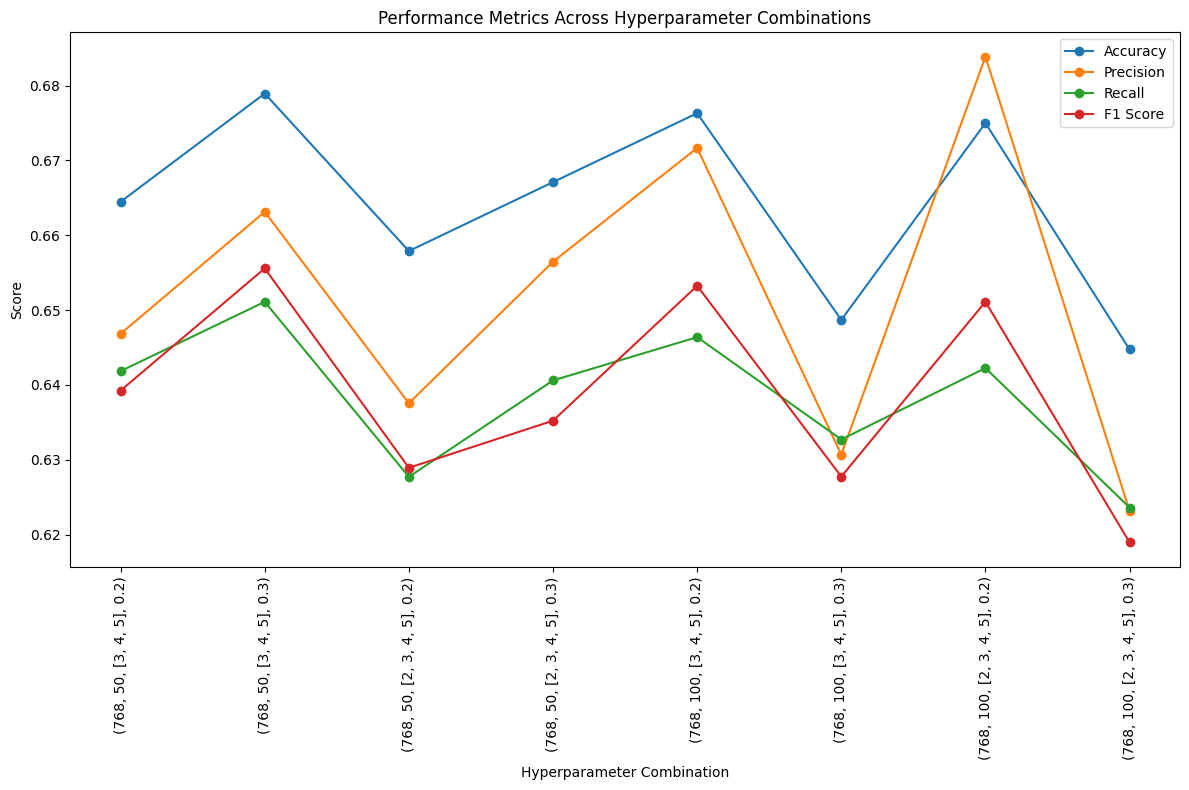

In [24]:
import itertools

# Define hyperparameter grid
param_grid = {
    'embedding_dim': [768],
    'num_filters': [50, 100],
    'kernel_sizes': [[3, 4, 5], [2, 3, 4, 5]],
    'dropout_rate': [0.2, 0.3],
}

all_combinations = list(itertools.product(
    param_grid['embedding_dim'],
    param_grid['num_filters'],
    param_grid['kernel_sizes'],
    param_grid['dropout_rate']
))

# Hyperparameter tuning loop with status bar
results = []
num_labels = len(df['label'].unique())

for emb_dim, num_filt, kernels, drop in tqdm(all_combinations, desc='Hyperparameter Tuning'):
    model = SinbertCNN(
        num_labels=num_labels,
        embedding_dim=emb_dim,
        num_filters=num_filt,
        kernel_sizes=kernels,
        dropout_rate=drop
    ).to(device)
    freeze_bottom_layers(model)
    optimizer = AdamW([
        {'params': model.sinbert.parameters(), 'lr': 2e-5},
        {'params': model.convs.parameters(),   'lr': 1e-4},
        {'params': model.fc.parameters(),      'lr': 1e-4},
    ], weight_decay=0.01)
    train_model_with_early_stopping(
        model=model,
        train_loader=train_data_loader,
        val_loader=test_data_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=10,      # Set higher epochs
        patience=2      # Early stopping patience
    )
    acc, precision, recall, f1 = evaluate_metrics(model, test_data_loader, device)
    results.append({
        'params': (emb_dim, num_filt, kernels, drop),
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

# After hyperparameter tuning loop
best_result = max(results, key=lambda x: x['accuracy'])
print('Best hyperparameters:', best_result['params'])
print('Best accuracy:', best_result['accuracy'])
print('Best precision:', best_result['precision'])
print('Best recall:', best_result['recall'])
print('Best F1:', best_result['f1'])

# Plot performance metrics for all hyperparameter combinations
accuracies = [r['accuracy'] for r in results]
precisions = [r['precision'] for r in results]
recalls = [r['recall'] for r in results]
f1s = [r['f1'] for r in results]
labels = [str(r['params']) for r in results]

plt.figure(figsize=(12, 8))
plt.plot(labels, accuracies, marker='o', label='Accuracy')
plt.plot(labels, precisions, marker='o', label='Precision')
plt.plot(labels, recalls, marker='o', label='Recall')
plt.plot(labels, f1s, marker='o', label='F1 Score')
plt.xticks(rotation=90)
plt.xlabel('Hyperparameter Combination')
plt.ylabel('Score')
plt.title('Performance Metrics Across Hyperparameter Combinations')
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
Res=results.copy()
Res

[{'params': (768, 50, [3, 4, 5], 0.2),
  'accuracy': 0.6644736842105263,
  'precision': 0.6468313356809835,
  'recall': 0.6418435127674258,
  'f1': 0.6392436423915017},
 {'params': (768, 50, [3, 4, 5], 0.3),
  'accuracy': 0.6789473684210526,
  'precision': 0.6631461251674726,
  'recall': 0.6511079310951434,
  'f1': 0.655574621873724},
 {'params': (768, 50, [2, 3, 4, 5], 0.2),
  'accuracy': 0.6578947368421053,
  'precision': 0.6375493958382915,
  'recall': 0.6277131625597099,
  'f1': 0.6289212534570684},
 {'params': (768, 50, [2, 3, 4, 5], 0.3),
  'accuracy': 0.6671052631578948,
  'precision': 0.6564700540294769,
  'recall': 0.6405982320464417,
  'f1': 0.6352159630008197},
 {'params': (768, 100, [3, 4, 5], 0.2),
  'accuracy': 0.6763157894736842,
  'precision': 0.6716750498136684,
  'recall': 0.6463867068566558,
  'f1': 0.6532464206305084},
 {'params': (768, 100, [3, 4, 5], 0.3),
  'accuracy': 0.6486842105263158,
  'precision': 0.6306888668116896,
  'recall': 0.6327028275078147,
  'f1': 

## Validation

#### 5 fold cross validation

In [26]:
from sklearn.model_selection import KFold

results_new=[]
import numpy as np
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

k_folds = 5
kfolds = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
labels = df['label'].values
texts = df['text'].tolist()
num_labels = 6
fold_results = []
train_losses_all = []
val_losses_all = []
all_labels_cv = []
all_preds_cv = []
final_results_after_cross_val=[]


for fold, (train_idx, val_idx) in enumerate(kfolds.split(texts, labels)):
    print(f"Fold {fold+1}/{k_folds}")
    train_texts = [texts[i] for i in train_idx]
    train_labels = [labels[i] for i in train_idx]
    val_texts = [texts[i] for i in val_idx]
    val_labels = [labels[i] for i in val_idx]

    train_dataset = SinhalaEmotionDataset(train_texts, train_labels, tokenizer)
    val_dataset = SinhalaEmotionDataset(val_texts, val_labels, tokenizer)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
    # Initialize a new model for each fold
    model = SinbertCNN(
        num_labels=6,
        embedding_dim=768,
        num_filters=100,
        kernel_sizes=[3,4,5],
        dropout_rate=0.3
    ).to(device)
    freeze_bottom_layers(model)

    optimizer = AdamW([
        {'params': model.sinbert.parameters(), 'lr': 2e-5},
        {'params': model.convs.parameters(),   'lr': 1e-4},
        {'params': model.fc.parameters(),      'lr': 1e-4},
    ], weight_decay=0.01)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    train_losses, train_accuracies, val_losses, val_accuracies = train_model_with_early_stopping(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=10,
        patience=2
    )
    train_losses_all.append(train_losses)
    val_losses_all.append(val_losses)
    acc, precision, recall, f1 = evaluate_metrics(model, val_loader, device)

    model.eval()
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_batch = batch['labels'].cpu().numpy()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds_batch = torch.argmax(outputs, dim=1).cpu().numpy()
            all_labels_cv.extend(labels_batch)
            all_preds_cv.extend(preds_batch)


    final_results_after_cross_val.append({
    'fold': fold + 1,
    'accuracy': acc,
    'precision': precision,
    'recall': recall,
    'f1': f1
    })

Fold 1/5


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: NLPC-UOM/SinBERT-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Frozen: embeddings + bottom 12 encoder layers | Trainable: 1,514,298/126,901,818 (1.2%)
Epoch 1/10 - Train Loss: 1.5052, Train Acc: 0.4145, Val Loss: 1.3203, Val Acc: 0.5184
Epoch 2/10 - Train Loss: 1.1490, Train Acc: 0.5911, Val Loss: 1.2095, Val Acc: 0.5829
Epoch 3/10 - Train Loss: 0.9976, Train Acc: 0.6543, Val Loss: 1.1124, Val Acc: 0.6053
Epoch 4/10 - Train Loss: 0.8812, Train Acc: 0.6839, Val Loss: 1.1157, Val Acc: 0.6184
Epoch 5/10 - Train Loss: 0.7827, Train Acc: 0.7286, Val Loss: 1.0412, Val Acc: 0.6329
Epoch 6/10 - Train Loss: 0.6954, Train Acc: 0.7730, Val Loss: 1.0677, Val Acc: 0.6276
Epoch 7/10 - Train Loss: 0.6311, Train Acc: 0.7855, Val Loss: 1.0592, Val Acc: 0.6526
Early stopping at epoch 7
Fold 2/5


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

[transformers] RobertaModel LOAD REPORT from: NLPC-UOM/SinBERT-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Frozen: embeddings + bottom 12 encoder layers | Trainable: 1,514,298/126,901,818 (1.2%)
Epoch 1/10 - Train Loss: 1.5244, Train Acc: 0.4013, Val Loss: 1.2724, Val Acc: 0.5632
Epoch 2/10 - Train Loss: 1.1782, Train Acc: 0.5760, Val Loss: 1.1672, Val Acc: 0.6276
Epoch 3/10 - Train Loss: 0.9968, Train Acc: 0.6543, Val Loss: 1.0984, Val Acc: 0.6184
Epoch 4/10 - Train Loss: 0.8826, Train Acc: 0.6951, Val Loss: 1.0791, Val Acc: 0.6145
Epoch 5/10 - Train Loss: 0.7884, Train Acc: 0.7375, Val Loss: 1.0523, Val Acc: 0.6329
Epoch 6/10 - Train Loss: 0.6906, Train Acc: 0.7701, Val Loss: 1.0406, Val Acc: 0.6368
Epoch 7/10 - Train Loss: 0.6325, Train Acc: 0.7786, Val Loss: 1.0250, Val Acc: 0.6421
Epoch 8/10 - Train Loss: 0.5536, Train Acc: 0.8240, Val Loss: 1.0466, Val Acc: 0.6500
Epoch 9/10 - Train Loss: 0.5026, Train Acc: 0.8388, Val Loss: 1.0193, Val Acc: 0.6658
Epoch 10/10 - Train Loss: 0.4335, Train Acc: 0.8674, Val Loss: 1.0156, Val Acc: 0.6395
Fold 5/5


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: NLPC-UOM/SinBERT-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Frozen: embeddings + bottom 12 encoder layers | Trainable: 1,514,298/126,901,818 (1.2%)
Epoch 1/10 - Train Loss: 1.5060, Train Acc: 0.4109, Val Loss: 1.2227, Val Acc: 0.5882
Epoch 2/10 - Train Loss: 1.1644, Train Acc: 0.5780, Val Loss: 1.1356, Val Acc: 0.6132
Epoch 3/10 - Train Loss: 0.9927, Train Acc: 0.6428, Val Loss: 1.0827, Val Acc: 0.6276
Epoch 4/10 - Train Loss: 0.8770, Train Acc: 0.6928, Val Loss: 1.0531, Val Acc: 0.6355
Epoch 5/10 - Train Loss: 0.7805, Train Acc: 0.7372, Val Loss: 1.0362, Val Acc: 0.6474
Epoch 6/10 - Train Loss: 0.6905, Train Acc: 0.7701, Val Loss: 1.0433, Val Acc: 0.6487
Epoch 7/10 - Train Loss: 0.6339, Train Acc: 0.7954, Val Loss: 1.0196, Val Acc: 0.6605
Epoch 8/10 - Train Loss: 0.5584, Train Acc: 0.8201, Val Loss: 1.0231, Val Acc: 0.6421
Epoch 9/10 - Train Loss: 0.4968, Train Acc: 0.8391, Val Loss: 0.9994, Val Acc: 0.6526
Epoch 10/10 - Train Loss: 0.4322, Train Acc: 0.8691, Val Loss: 1.0153, Val Acc: 0.6461


In [27]:
    final_results_after_cross_val

[{'fold': 1,
  'accuracy': 0.6328947368421053,
  'precision': 0.6069156581849334,
  'recall': 0.6143532896250288,
  'f1': 0.6086967283427346},
 {'fold': 2,
  'accuracy': 0.6342105263157894,
  'precision': 0.5947235836489366,
  'recall': 0.6272913875695205,
  'f1': 0.6023177339134422},
 {'fold': 3,
  'accuracy': 0.6552631578947369,
  'precision': 0.625692462701558,
  'recall': 0.6368546935682486,
  'f1': 0.6250321985216095},
 {'fold': 4,
  'accuracy': 0.6394736842105263,
  'precision': 0.6312965366458474,
  'recall': 0.6271193622376486,
  'f1': 0.6266392621129703},
 {'fold': 5,
  'accuracy': 0.6460526315789473,
  'precision': 0.6456028981515688,
  'recall': 0.6321724826584528,
  'f1': 0.6342920208111429}]

#### final evaluation metrics after cross validation

In [28]:
import numpy as np

# Extract metrics from each fold
accuracies = [fold['accuracy'] for fold in final_results_after_cross_val]
precisions = [fold['precision'] for fold in final_results_after_cross_val]
recalls = [fold['recall'] for fold in final_results_after_cross_val]
f1s = [fold['f1'] for fold in final_results_after_cross_val]

# Compute averages
avg_accuracy = np.mean(accuracies)
avg_precision = np.mean(precisions)
avg_recall = np.mean(recalls)
avg_f1 = np.mean(f1s)

print("Macro Performance")
print(f"Average Accuracy: {avg_accuracy:.4f}")
print(f"Average Precision: {avg_precision:.4f}")
print(f"Average Recall: {avg_recall:.4f}")
print(f"Average F1 Score: {avg_f1:.4f}")

Macro Performance
Average Accuracy: 0.6416
Average Precision: 0.6208
Average Recall: 0.6276
Average F1 Score: 0.6194


#### Training and Validation Loss Plots

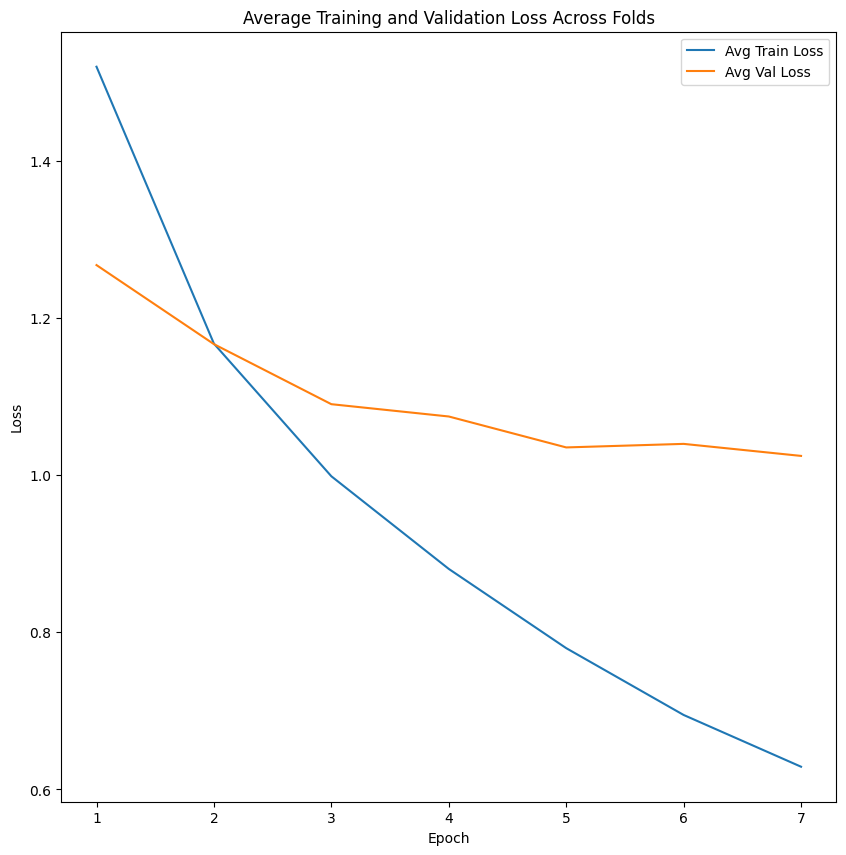

In [29]:


# Find the minimum length among all folds
min_len = min(len(l) for l in train_losses_all)

# Truncate all loss lists to min_len
train_losses_trimmed = [l[:min_len] for l in train_losses_all]
val_losses_trimmed = [l[:min_len] for l in val_losses_all]

# Now average
avg_train_loss = np.mean(train_losses_trimmed, axis=0)
avg_val_loss = np.mean(val_losses_trimmed, axis=0)

plt.figure(num=1,figsize=(10,10))
plt.plot(range(1, len(avg_train_loss)+1), avg_train_loss, label='Avg Train Loss')
plt.plot(range(1, len(avg_val_loss)+1), avg_val_loss, label='Avg Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Average Training and Validation Loss Across Folds')
plt.xticks(range(1, len(avg_train_loss)+1))
plt.show()

#### Global(Micro) Performance

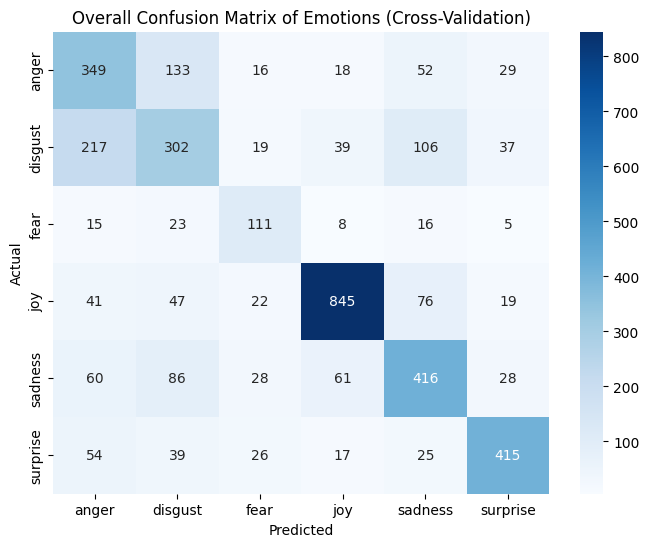

In [30]:
 #Compute overall confusion matrix
emotion_names = sorted(set(df['label'].values))
cm = confusion_matrix(all_labels_cv, all_preds_cv)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotion_names, yticklabels=emotion_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Overall Confusion Matrix of Emotions (Cross-Validation)')
plt.show()

## Final Test Set Evaluation
Train one final model on the full 80% training data and evaluate once on the held-out 20% test set.

In [31]:
final_model = SinbertCNN(
    num_labels=6, embedding_dim=768, num_filters=100,
    kernel_sizes=[3, 4, 5], dropout_rate=0.3
).to(device)
freeze_bottom_layers(final_model)

optimizer = AdamW([
    {'params': final_model.sinbert.parameters(), 'lr': 2e-5},
    {'params': final_model.convs.parameters(),   'lr': 1e-4},
    {'params': final_model.fc.parameters(),      'lr': 1e-4},
], weight_decay=0.01)
criterion_final = nn.CrossEntropyLoss(weight=class_weights)

train_model_with_early_stopping(
    model=final_model, train_loader=train_data_loader,
    val_loader=test_data_loader, criterion=criterion_final,
    optimizer=optimizer, device=device, epochs=10, patience=2
)

acc, precision, recall, f1 = evaluate_metrics(final_model, test_data_loader, device)
print('=' * 50)
print('Final Test Set Evaluation (SinBERT+CNN)')
print('=' * 50)
print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1 Score:  {f1:.4f}')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: NLPC-UOM/SinBERT-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Frozen: embeddings + bottom 12 encoder layers | Trainable: 1,514,298/126,901,818 (1.2%)
Epoch 1/10 - Train Loss: 1.5431, Train Acc: 0.4049, Val Loss: 1.2287, Val Acc: 0.5513
Epoch 2/10 - Train Loss: 1.1445, Train Acc: 0.5859, Val Loss: 1.0782, Val Acc: 0.6066
Epoch 3/10 - Train Loss: 1.0009, Train Acc: 0.6411, Val Loss: 1.0744, Val Acc: 0.6105
Epoch 4/10 - Train Loss: 0.8741, Train Acc: 0.6865, Val Loss: 1.0126, Val Acc: 0.6605
Epoch 5/10 - Train Loss: 0.7755, Train Acc: 0.7438, Val Loss: 0.9776, Val Acc: 0.6500
Epoch 6/10 - Train Loss: 0.6894, Train Acc: 0.7664, Val Loss: 0.9505, Val Acc: 0.6592
Epoch 7/10 - Train Loss: 0.6216, Train Acc: 0.7934, Val Loss: 0.9856, Val Acc: 0.6579
Epoch 8/10 - Train Loss: 0.5567, Train Acc: 0.8112, Val Loss: 0.9469, Val Acc: 0.6697
Epoch 9/10 - Train Loss: 0.4937, Train Acc: 0.8365, Val Loss: 0.9326, Val Acc: 0.6618
Epoch 10/10 - Train Loss: 0.4509, Train Acc: 0.8559, Val Loss: 0.9931, Val Acc: 0.6697
Final Test Set Evaluation (SinBERT+CNN)
Accuracy:  